In [ ]:
import os
from pathlib import Path
from copy import deepcopy

from tqdm import trange, tqdm

import cantera as ct
import numpy as np
import matplotlib.pyplot as plt

from chem_operator.utils import to_numpy, get_species_names
from chem_operator.datasets import (
    CaseParameters, CaseSimulator, SimulationRecord, SimulationDatasetGenerator, ChemOperatorDataset    
)

import torch

prog_path = Path(os.path.abspath(""))

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [13]:
dataset = ChemOperatorDataset(
    path=prog_path.parent / "datasets" / "pfr" / "pfr_non_isothermal_chain_of_reactors_train.h5",
    full_trajectory_mode=True,
    dtype=torch.float32,
    coordinate_name="z"
    # n_steps_input=n_steps_input,
    # n_steps_output=n_steps_output,
    # dt_stride=dt_stride,
    # state_variables=state_variables,
    # time_key=time_key,
    # trajectory_parameters=trajectory_parameters,
)

In [14]:
dataset[0]["output_coordinates"].keys()

dict_keys(['z'])

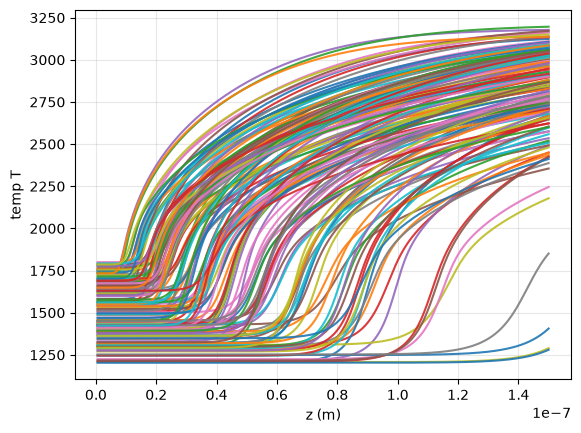

In [ ]:
fig, ax = plt.subplots() # figsize=(8, 5)

for i in range(len(dataset)):
    sample = dataset[i]

    # species_names = get_species_names(sample)
    # co_idx = species_names.index("CO")

    z = to_numpy(sample["output_coordinates"]["z"])
    # x = to_numpy(sample["output_fields"]["X"])[:, co_idx]
    T = to_numpy(sample["output_fields"]["T"])
    # t_in = to_numpy(sample["input_coordinates"]["time"]).reshape(-1)
    # x_in = to_numpy(sample["input_fields"]["X"])[:, co_idx].reshape(-1)

    # t = np.concatenate([t_in, t_out])
    # x_co = np.concatenate([x_in, x_out])

    ax.plot(z, T, alpha=0.9) # linewidth=2

ax.set_xlabel("$z$ (m)")
ax.set_ylabel(r"$T$ (K)")
# ax.set_title(f"CO mole fraction across time for {n} states")
ax.grid(True, alpha=0.3)